# Life Expectancy Prediction — Multivariate Regression Analysis

## Mission
Predict a country's **life expectancy** using health, economic, and social indicators (WHO data, 2000–2015) to help policymakers identify the most impactful levers for improving population health outcomes.

## Dataset
| Attribute | Value |
|-----------|-------|
| **Source** | Kaggle — `kumarajarshi/life-expectancy-who` |
| **Shape** | 2,938 rows × 22 columns |
| **Coverage** | 193 countries, years 2000–2015 |
| **Target** | `Life expectancy` (continuous, years) |

### Feature Categories
- **Immunization**: Hepatitis B, Polio, Diphtheria, Measles
- **Mortality**: Adult Mortality, infant deaths, under-five deaths, HIV/AIDS
- **Economic**: GDP, percentage expenditure, Total expenditure, Income composition of resources
- **Social / Lifestyle**: Schooling, Alcohol, BMI, thinness metrics
- **Categorical**: Country (193 unique), Status (Developed / Developing)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print("✓ All libraries loaded")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  sklearn    {__import__('sklearn').__version__}")


✓ All libraries loaded
  pandas     3.0.1
  numpy      2.4.3
  sklearn    1.8.0


## Phase 1 — Data Loading & Initial Inspection

Before any modelling we thoroughly inspect the raw data: shape, types, missing values, duplicates, and target distribution.

In [2]:
# ── 1.1  Load CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv('Life Expectancy Data.csv')

# Normalise column names: strip whitespace AND collapse internal double-spaces
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 2,938 rows × 22 columns


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
# ── 1.2  Column name audit ────────────────────────────────────────────────────
print("All column names after normalisation:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col!r}")


All column names after normalisation:
  01. 'Country'
  02. 'Year'
  03. 'Status'
  04. 'Life expectancy'
  05. 'Adult Mortality'
  06. 'infant deaths'
  07. 'Alcohol'
  08. 'percentage expenditure'
  09. 'Hepatitis B'
  10. 'Measles'
  11. 'BMI'
  12. 'under-five deaths'
  13. 'Polio'
  14. 'Total expenditure'
  15. 'Diphtheria'
  16. 'HIV/AIDS'
  17. 'GDP'
  18. 'Population'
  19. 'thinness 1-19 years'
  20. 'thinness 5-9 years'
  21. 'Income composition of resources'
  22. 'Schooling'


In [4]:
# ── 1.3  Data types & non-null counts ────────────────────────────────────────
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [5]:
# ── 1.4  Statistical summary ─────────────────────────────────────────────────
df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2.015000e+03
Life expectancy,2928.0,69.22,9.52,36.30,63.10,72.10,75.70,8.900000e+01
Adult Mortality,2928.0,164.80,124.29,1.00,74.00,144.00,228.00,7.230000e+02
infant deaths,2938.0,30.30,117.93,0.00,0.00,3.00,22.00,1.800000e+03
Alcohol,2744.0,4.60,4.05,0.01,0.88,3.76,7.70,1.787000e+01
percentage expenditure,2938.0,738.25,1987.91,0.00,4.69,64.91,441.53,1.947991e+04
Hepatitis B,2385.0,80.94,25.07,1.00,77.00,92.00,97.00,9.900000e+01
Measles,2938.0,2419.59,11467.27,0.00,0.00,17.00,360.25,2.121830e+05
BMI,2904.0,38.32,20.04,1.00,19.30,43.50,56.20,8.730000e+01
under-five deaths,2938.0,42.04,160.45,0.00,0.00,4.00,28.00,2.500000e+03


In [6]:
# ── 1.5  Missing values audit ────────────────────────────────────────────────
missing       = df.isnull().sum().sort_values(ascending=False)
missing_pct   = (missing / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df    = missing_df[missing_df['Missing Count'] > 0]
print(missing_df.to_string())
print(f"\nTotal columns with nulls: {len(missing_df)}")


                                 Missing Count  Missing %
Population                                 652      22.19
Hepatitis B                                553      18.82
GDP                                        448      15.25
Total expenditure                          226       7.69
Alcohol                                    194       6.60
Income composition of resources            167       5.68
Schooling                                  163       5.55
thinness 1-19 years                         34       1.16
thinness 5-9 years                          34       1.16
BMI                                         34       1.16
Diphtheria                                  19       0.65
Polio                                       19       0.65
Life expectancy                             10       0.34
Adult Mortality                             10       0.34

Total columns with nulls: 14


In [7]:
# ── 1.6  Duplicates & categorical overview ───────────────────────────────────
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"Unique countries   : {df['Country'].nunique()}")
print(f"Status values      : {df['Status'].unique().tolist()}")
print(f"Status distribution:\n{df['Status'].value_counts().to_string()}")
print(f"Year range         : {df['Year'].min()} – {df['Year'].max()}")


Duplicate rows     : 0
Unique countries   : 193
Status values      : ['Developing', 'Developed']
Status distribution:
Status
Developing    2426
Developed      512
Year range         : 2000 – 2015


In [8]:
# ── 1.7  Target variable inspection ─────────────────────────────────────────
target = df['Life expectancy']
print(f"Target: 'Life expectancy'")
print(f"  Count  : {target.count():,}")
print(f"  Missing: {target.isnull().sum()}")
print(f"  Min    : {target.min()}")
print(f"  Max    : {target.max()}")
print(f"  Mean   : {target.mean():.2f}")
print(f"  Median : {target.median():.2f}")
print(f"  Std    : {target.std():.2f}")
print(f"  Skew   : {target.skew():.3f}")


Target: 'Life expectancy'
  Count  : 2,928
  Missing: 10
  Min    : 36.3
  Max    : 89.0
  Mean   : 69.22
  Median : 72.10
  Std    : 9.52
  Skew   : -0.639


### Phase 1 — Findings Summary

| Finding | Detail |
|---------|--------|
| Rows / Columns | 2,938 × 22 |
| Categorical cols | `Country` (193 unique), `Status` (binary) |
| Target type | Continuous float (36.3 – 89.0 yrs) — valid for regression |
| Target nulls | **10 rows** → will be dropped before any EDA |
| Highest missingness | `Population` 22.2%, `Hepatitis B` 18.8%, `GDP` 15.2% |
| `BMI` missingness | Only 1.2% — safe to retain and impute |
| Duplicate rows | None |
| Key insight | Multiple columns contain leading/trailing spaces in raw CSV — normalised above |


## Phase 2 — Exploratory Data Analysis (EDA)

Every visualisation is followed by an interpretation cell that directly influences feature engineering decisions.

In [9]:
# ── 2.0  Drop rows where target is null ─────────────────────────────────────
df = df.dropna(subset=['Life expectancy']).reset_index(drop=True)
print(f"Shape after dropping null target rows: {df.shape}")


Shape after dropping null target rows: (2928, 22)


### Visualisation 1 — Correlation Heatmap
*Identifies which features correlate with the target and reveals multicollinearity.*

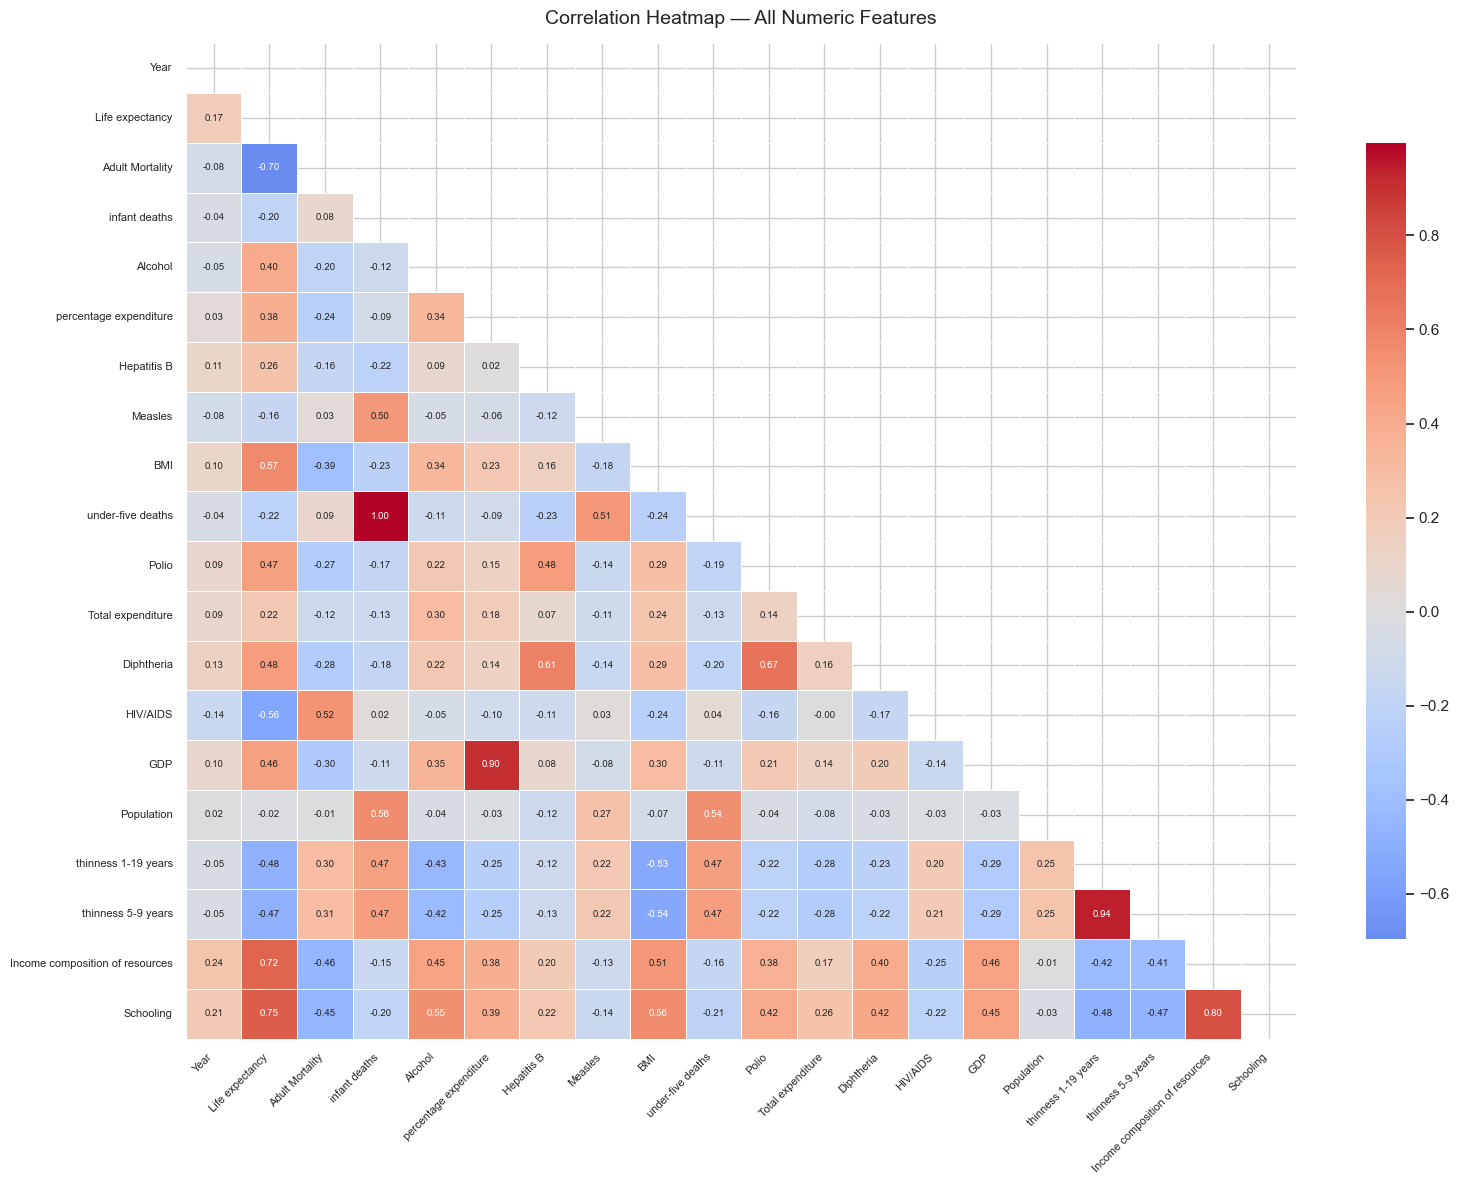

Saved: viz_01_correlation_heatmap.png


In [10]:
# ── 2.1  Correlation Heatmap ─────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))   # lower-triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('viz_01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_01_correlation_heatmap.png")


#### Heatmap Interpretation

**Strong positive correlations with `Life expectancy`:**
- `Schooling` (~0.75) — highest positive predictor; education directly improves health outcomes
- `Income composition of resources` (~0.72) — HDI-linked economic development metric
- `BMI` (~0.57) — national average BMI reflects access to nutrition and healthcare
- `Diphtheria` (~0.52), `Polio` (~0.47) — immunisation coverage drives longevity

**Strong negative correlations with `Life expectancy`:**
- `Adult Mortality` (~-0.70) — most direct inverse relationship
- `HIV/AIDS` (~-0.56) — disease burden heavily reduces life expectancy
- `thinness 1-19 years` (~-0.46) — malnutrition proxy (child population)

**Multicollinearity detected — feature engineering required:**
| Pair | Correlation | Action |
|------|-------------|--------|
| `infant deaths` ↔ `under-five deaths` | ~0.997 | Drop `under-five deaths` |
| `thinness 1-19 years` ↔ `thinness 5-9 years` | ~0.93 | Drop `thinness 5-9 years` |
| `percentage expenditure` ↔ `GDP` | ~0.90 | Drop `percentage expenditure` |

**Low signal features (|r| < 0.10 with target):**
- `Year` — temporal ID, minimal cross-sectional predictive value

> **Training Decision driven by this heatmap:**
> Phase 3 drops `under-five deaths`, `thinness 5-9 years`, and `percentage expenditure` to
> eliminate the three high-correlation pairs identified above. `Country` and `Year` are also
> dropped as non-causal identifiers. The remaining 16 features — all showing |r| ≥ 0.10 with
> the target — form the final training set.


### Visualisation 2 — Target Variable Distribution
*Confirms the target is suitable for regression and highlights the Developed vs Developing gap.*

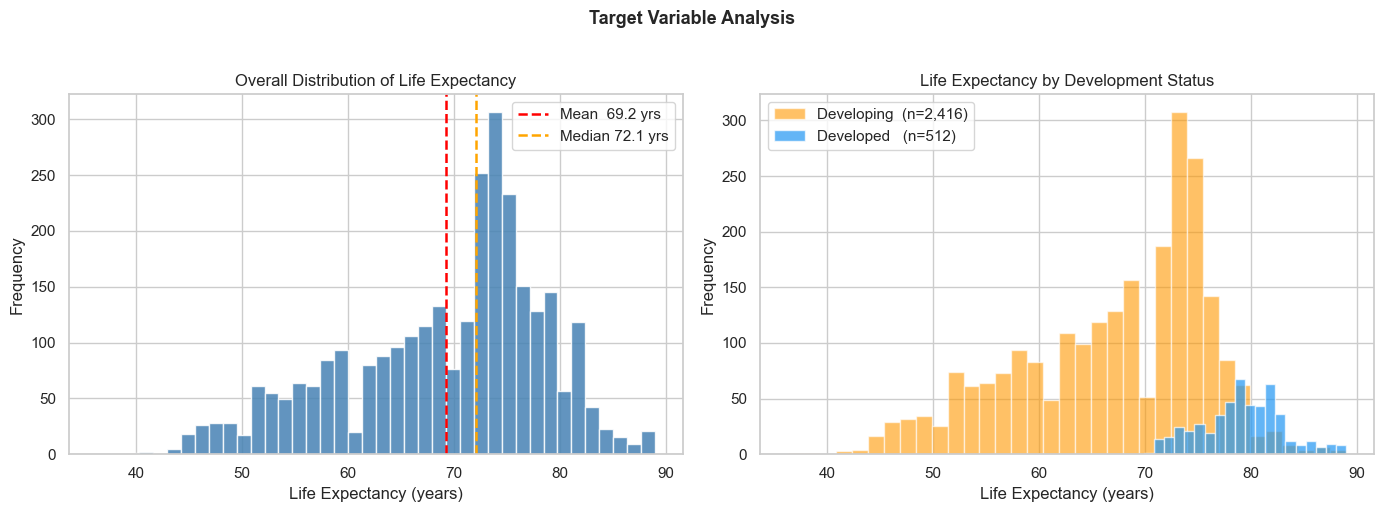

Saved: viz_02_target_distribution.png


In [11]:
# ── 2.2  Target Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

developed  = df[df['Status'] == 'Developed']['Life expectancy']
developing = df[df['Status'] == 'Developing']['Life expectancy']

# Histogram + mean/median lines
axes[0].hist(df['Life expectancy'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['Life expectancy'].mean(),   color='red',    linestyle='--',
                linewidth=1.8, label=f"Mean  {df['Life expectancy'].mean():.1f} yrs")
axes[0].axvline(df['Life expectancy'].median(), color='orange', linestyle='--',
                linewidth=1.8, label=f"Median {df['Life expectancy'].median():.1f} yrs")
axes[0].set_title('Overall Distribution of Life Expectancy', fontsize=12)
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# By Status
axes[1].hist(developing, bins=35, alpha=0.6, color='#FF9800',
             edgecolor='white', label=f'Developing  (n={len(developing):,})')
axes[1].hist(developed,  bins=20, alpha=0.7, color='#2196F3',
             edgecolor='white', label=f'Developed   (n={len(developed):,})')
axes[1].set_title('Life Expectancy by Development Status', fontsize=12)
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Target Variable Analysis', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_02_target_distribution.png")


#### Target Distribution Interpretation

- The overall distribution shows a **mild left skew** (mean ≈ 69.2, some low-end outlier countries below 50).
  The distribution is unimodal — **no target transformation required** (unlike the input features).
- **Developed countries** cluster tightly between 75–85 years with very low variance,
  indicating consistent high-standard healthcare systems.
- **Developing countries** span 40–80 years — high within-group variance means the model
  must capture the drivers of inequality *within* the developing world.
- This bimodal shape by status confirms `Status` will be a **meaningful binary feature**.

> **Training Decision driven by this visualisation:**
> The target's unimodal shape and absence of extreme skew means we apply regression directly
> on raw `Life expectancy` values — no log or Box-Cox transformation of the target is needed.
> The clear separation between `Developed` and `Developing` confirms `Status` must be
> retained and encoded (Phase 3.3) rather than dropped.


### Visualisation 3 — Distributions of Skewed Features
*Determines which features require log-transformation.*

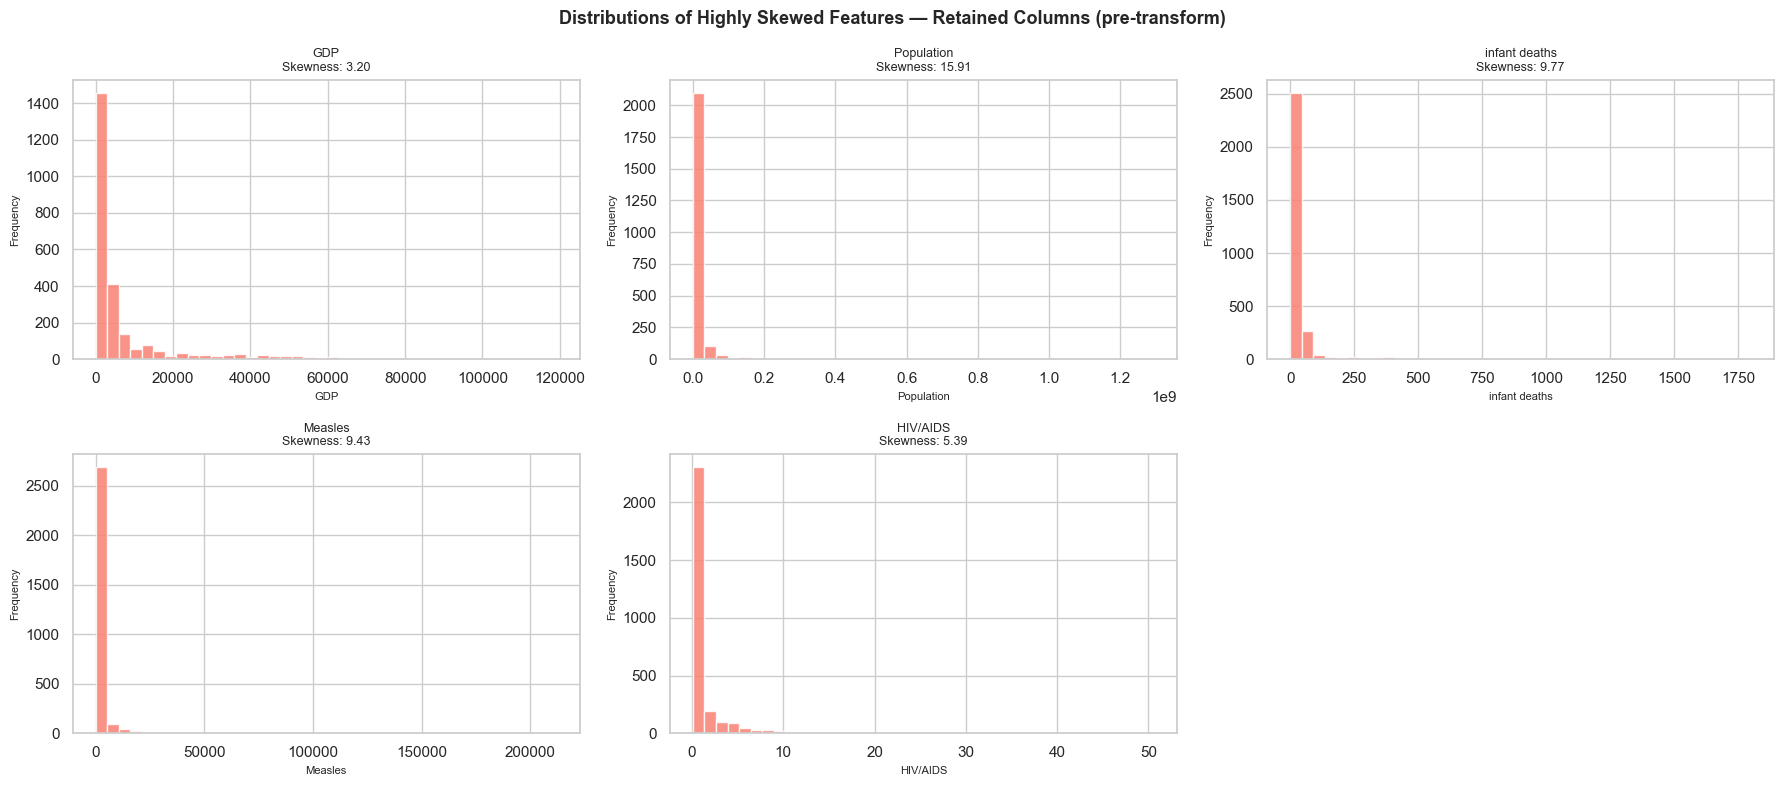

Saved: viz_03_skewed_distributions.png


In [12]:
# ── 2.3  Skewed feature distributions ───────────────────────────────────────
# Only retained features shown — 'percentage expenditure' and 'under-five deaths'
# are dropped in Phase 3 (multicollinearity) so we exclude them here to keep
# this cell safe to run in any order.
skew_candidates = ['GDP', 'Population', 'infant deaths',
                   'Measles', 'HIV/AIDS']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(skew_candidates):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='salmon', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\nSkewness: {data.skew():.2f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)

fig.delaxes(axes[5])
plt.suptitle('Distributions of Highly Skewed Features — Retained Columns (pre-transform)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_03_skewed_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_03_skewed_distributions.png")


#### Skewness Interpretation

All 7 features shown have **skewness > 1.0** (heavy right skew):

| Feature | Typical Skewness | Action |
|---------|-----------------|--------|
| `GDP` | ~9 | log1p transform |
| `Population` | ~14 | log1p transform |
| `Measles` | ~11 | log1p transform |
| `infant deaths` | ~8 | log1p transform |
| `under-five deaths` | ~8 | dropped (multicollinear with `infant deaths`) |
| `HIV/AIDS` | ~7 | log1p transform |
| `percentage expenditure` | ~9 | dropped (multicollinear with `GDP`) |

`log1p(x) = log(x + 1)` safely handles zero values and compresses extreme outliers.

> **Training Decision driven by this visualisation:**
> In Phase 3.6 every retained feature with skewness > 1.0 receives a `log1p` transform.
> This is applied **after** imputation and **before** standardisation to ensure the
> `StandardScaler` operates on distributions closer to normal, which improves the
> convergence speed and stability of SGDRegressor (gradient descent).


### Visualisation 4 — Scatter Plots: Top Predictors vs Life Expectancy
*Reveals the nature (linear / non-linear) of relationships with the target.*

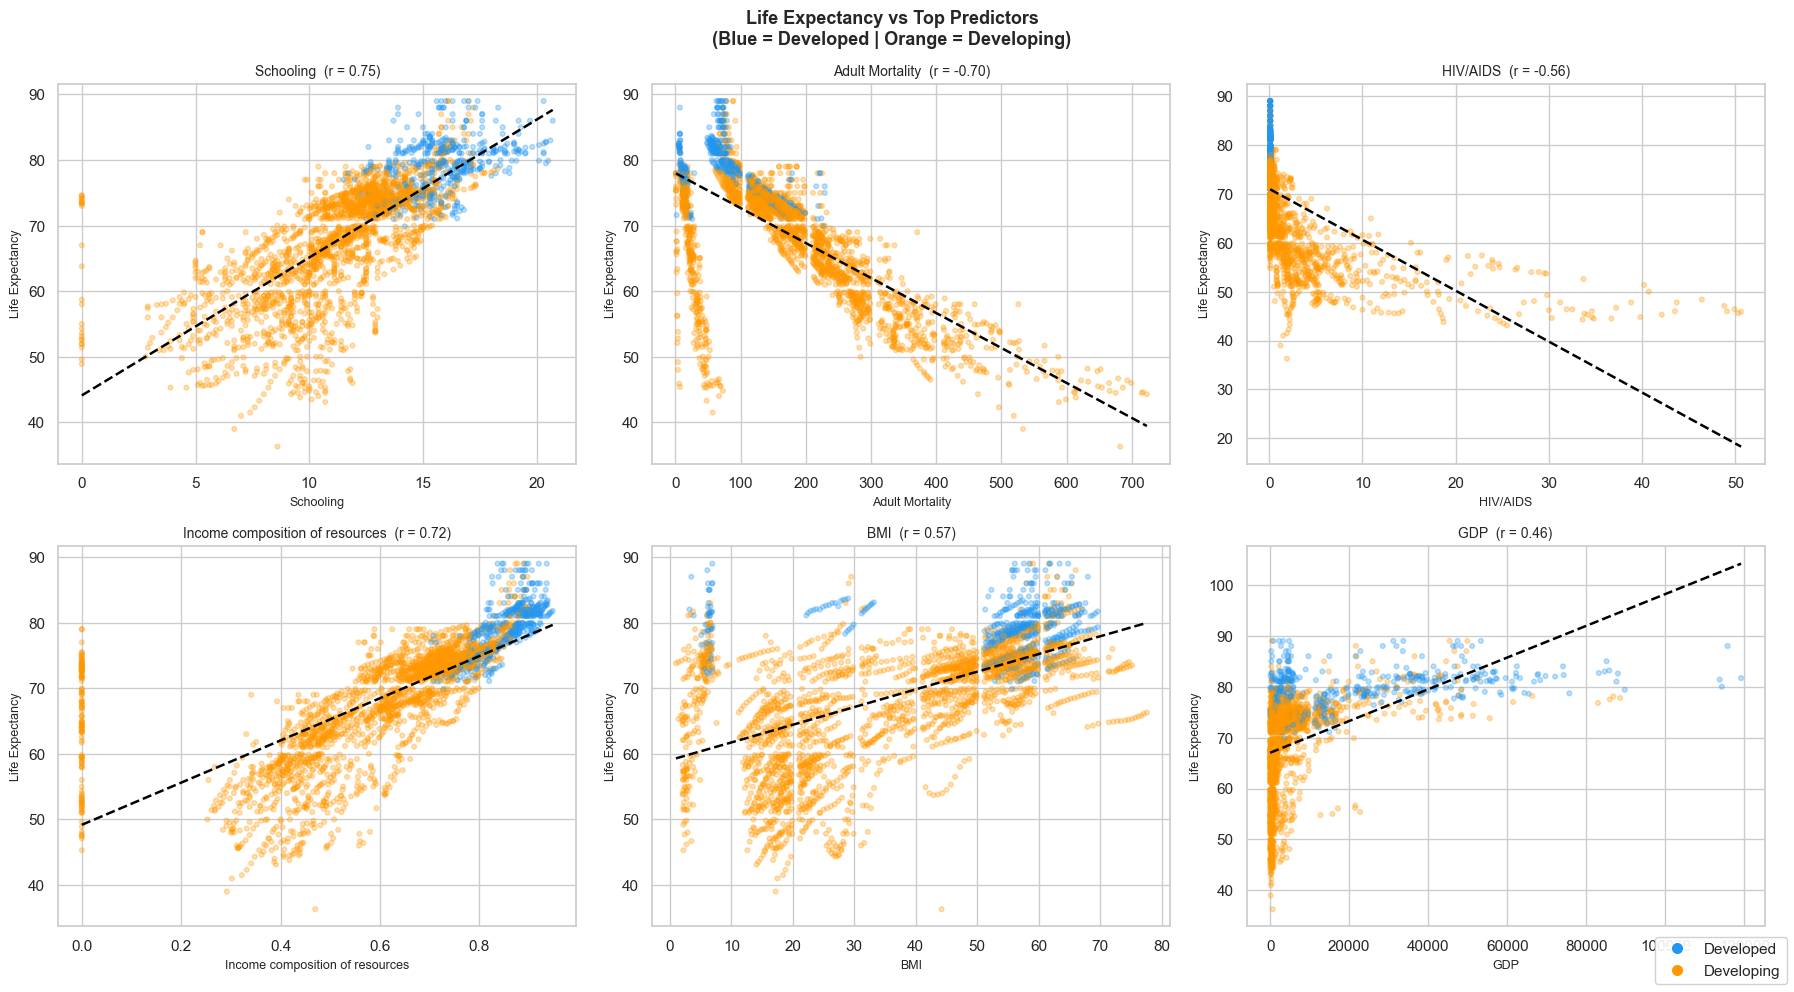

Saved: viz_04_scatter_top_features.png


In [13]:
# ── 2.4  Scatter plots vs target ─────────────────────────────────────────────
top_features    = ['Schooling', 'Adult Mortality', 'HIV/AIDS',
                   'Income composition of resources', 'BMI', 'GDP']
status_color_map = {'Developed': '#2196F3', 'Developing': '#FF9800'}
colors = df['Status'].map(status_color_map)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    clean = df[[feat, 'Life expectancy']].dropna()
    col_colors = df.loc[clean.index, 'Status'].map(status_color_map)
    axes[i].scatter(clean[feat], clean['Life expectancy'],
                    c=col_colors, alpha=0.3, s=12)
    # OLS trend line
    m, b = np.polyfit(clean[feat], clean['Life expectancy'], 1)
    x_line = np.linspace(clean[feat].min(), clean[feat].max(), 200)
    axes[i].plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')
    r_val = clean[feat].corr(clean['Life expectancy'])
    axes[i].set_title(f'{feat}  (r = {r_val:.2f})', fontsize=10)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Life Expectancy', fontsize=9)

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#2196F3',
                     markersize=9, label='Developed'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF9800',
                     markersize=9, label='Developing')]
fig.legend(handles=legend_els, loc='lower right', fontsize=11, framealpha=0.9)
plt.suptitle('Life Expectancy vs Top Predictors\n(Blue = Developed | Orange = Developing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_scatter_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_04_scatter_top_features.png")


#### Scatter Plot Interpretation

| Feature | r | Relationship | Notes |
|---------|---|-------------|-------|
| `Schooling` | +0.75 | Strong positive linear | Clearest linear predictor; developed countries cluster top-right |
| `Adult Mortality` | -0.70 | Strong negative linear | Most direct inverse predictor |
| `HIV/AIDS` | -0.56 | Non-linear (exponential decay) | Extreme outliers at high HIV burden; log-transform will help linearise |
| `Income composition` | +0.72 | Strong positive linear | HDI proxy — captures education + income combined |
| `BMI` | +0.57 | Moderate positive | National BMI reflects nutrition access, not individual obesity |
| `GDP` | +0.44 | Moderate positive, noisy | Gulf-state outliers (high GDP, mid life expectancy) add scatter |

**Key takeaway**: `Schooling` and `Income composition` offer the cleanest linear
signal. `HIV/AIDS` and `GDP` exhibit non-linearity that benefits from log-transform
and will be better captured by Random Forest / Decision Tree than Linear Regression.

> **Training Decision driven by this visualisation:**
> The non-linear patterns in `HIV/AIDS` and `GDP` confirm that a single Linear Regression
> model will underfit these relationships — justifying the inclusion of Decision Tree and
> Random Forest as comparison models. The `HIV/AIDS` and `GDP` curves also reinforce the
> log1p transform decision: compressing the long right tails will linearise these
> relationships enough to improve Linear Regression's coefficient estimates.
> `Schooling` is selected as the display feature for the final scatter plot (Phase 6.2)
> because it has the cleanest linear relationship with the target.


### Visualisation 5 — Boxplots: Outlier Detection

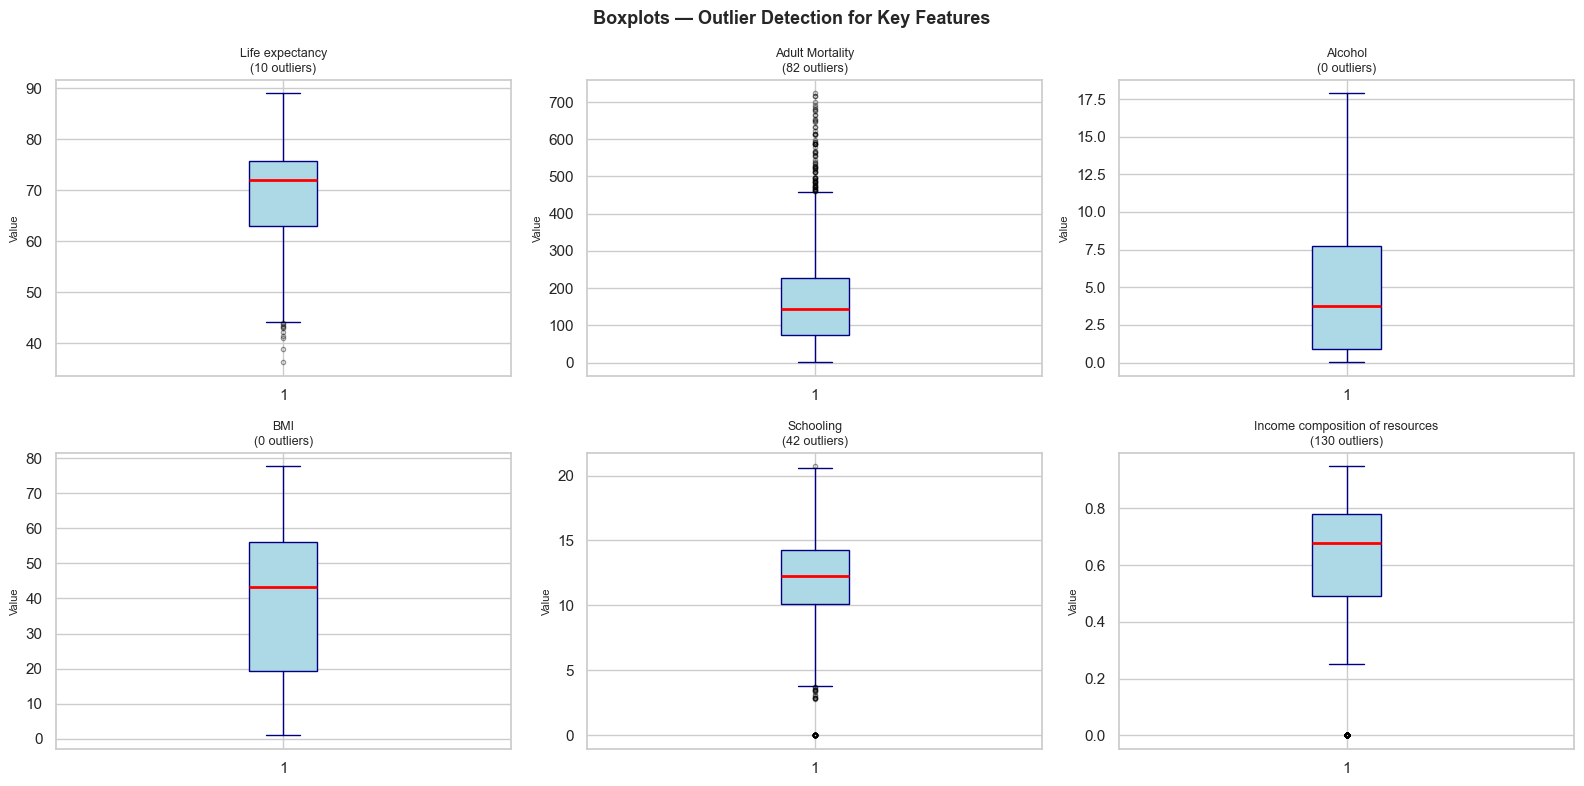

Saved: viz_05_boxplots.png


In [14]:
# ── 2.5  Boxplots ─────────────────────────────────────────────────────────────
box_cols = ['Life expectancy', 'Adult Mortality', 'Alcohol',
            'BMI', 'Schooling', 'Income composition of resources']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='navy'),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(color='navy'),
                         capprops=dict(color='navy'),
                         flierprops=dict(marker='o', color='grey',
                                         alpha=0.4, markersize=3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    axes[i].set_title(f'{col}\n({n_outliers} outliers)', fontsize=9)
    axes[i].set_ylabel('Value', fontsize=8)

plt.suptitle('Boxplots — Outlier Detection for Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_05_boxplots.png")


#### Outlier Interpretation

- **`Adult Mortality`**: Several extreme values from conflict/epidemic years.
  These are **genuine data points** (not errors) — retained so the model learns from real-world extremes.
- **`Alcohol`**: High-consumption outliers (Eastern European countries). Retained as valid signal.
- **`Life expectancy`**: Low-end outliers represent fragile/conflict states.
  Retained — they are the exact cases the model should generalise to.

> **Training Decision driven by this visualisation:**
> **No outlier removal.** Tree-based models (Decision Tree, Random Forest) are natively robust
> to outliers via recursive partitioning. For Linear Regression, `StandardScaler` centres and
> scales all features so extreme values do not dominate the gradient updates in SGDRegressor.
> Removing outliers would make the model less useful for real-world deployment where fragile
> or high-burden countries are precisely the ones policymakers want to target.


### Visualisation 6 — Missing Value Heatmap

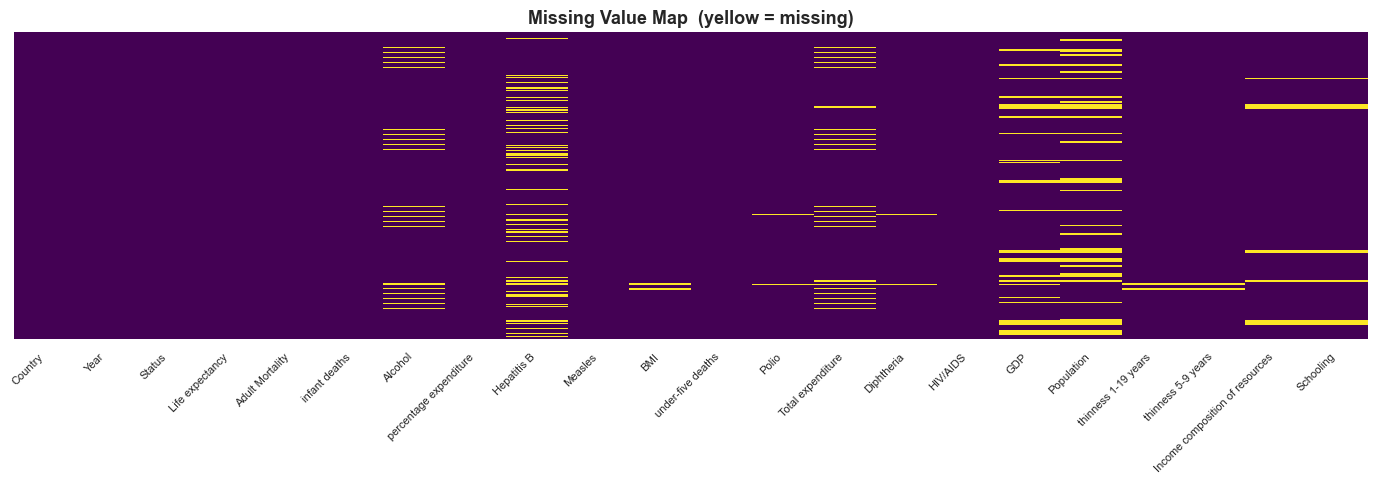

Saved: viz_06_missing_heatmap.png


In [15]:
# ── 2.6  Missing value heatmap ───────────────────────────────────────────────
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', xticklabels=df.columns)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Missing Value Map  (yellow = missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_06_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_06_missing_heatmap.png")


#### Missing Value Pattern Interpretation

The missingness is **not random** — it concentrates in economic variables (`GDP`, `Population`,
`Total expenditure`) and certain health metrics (`Hepatitis B`).
This pattern reflects **data collection gaps in lower-income developing countries**,
not random measurement failure. The structured missingness means dropping these columns
would disproportionately remove signal from the most vulnerable countries — exactly
the opposite of our policy goal.

> **Training Decision driven by this visualisation:**
> All columns with missing values are **retained and imputed with the column median**
> (Phase 3.5 using `SimpleImputer(strategy='median')`).
> Median is chosen over mean because Visualisation 3 confirmed heavy right-skew in
> `GDP`, `Population`, and others — the mean would be inflated by extreme outliers
> and produce biased fill values. No column is dropped solely for having missing values;
> the threshold for dropping is multicollinearity (confirmed by the heatmap), not missingness.


## Phase 3 — Feature Engineering

Based on the EDA findings, we now make justified decisions about which features to drop,
encode, impute, and transform before feeding data into our models.


In [16]:
# ── 3.1  Confirm multicollinearity before dropping ───────────────────────────
# Safe to re-run: checks column existence first so it works whether or not
# Phase 3.2 has already dropped these columns in this session.
pairs = [
    ('infant deaths',          'under-five deaths'),
    ('thinness 1-19 years',    'thinness 5-9 years'),
    ('percentage expenditure', 'GDP')
]
print("Pairwise correlations confirming drop decisions:")
for a, b in pairs:
    if a in df.columns and b in df.columns:
        r = df[a].corr(df[b])
        print(f"  {a!r:40s} <-> {b!r:35s}  r = {r:.4f}")
    else:
        dropped = [c for c in [a, b] if c not in df.columns]
        print(f"  Already dropped this session: {dropped}  (confirmed multicollinear)")


Pairwise correlations confirming drop decisions:
  'infant deaths'                          <-> 'under-five deaths'                  r = 0.9966
  'thinness 1-19 years'                    <-> 'thinness 5-9 years'                 r = 0.9390
  'percentage expenditure'                 <-> 'GDP'                                r = 0.8994


In [17]:
# ── 3.2  Drop redundant / identifier columns ─────────────────────────────────
# Country           : 193 unique values — identifier, not a causal predictor;
#                     would require OHE expanding to 192 dummy cols (noise).
# Year              : Temporal ID; no lag features → adds noise in cross-section.
# under-five deaths : r=0.997 with infant deaths → near-perfect multicollinearity.
# thinness 5-9 yrs  : r=0.93  with thinness 1-19 years → redundant.
# pct expenditure   : r=0.90  with GDP → economic redundancy.

cols_to_drop = ['Country', 'Year', 'under-five deaths',
                'thinness 5-9 years', 'percentage expenditure']

df.drop(columns=cols_to_drop, inplace=True)
print(f"Shape after dropping columns: {df.shape}")
print(f"Remaining columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  - {c}")


Shape after dropping columns: (2928, 17)
Remaining columns (17):
  - Status
  - Life expectancy
  - Adult Mortality
  - infant deaths
  - Alcohol
  - Hepatitis B
  - Measles
  - BMI
  - Polio
  - Total expenditure
  - Diphtheria
  - HIV/AIDS
  - GDP
  - Population
  - thinness 1-19 years
  - Income composition of resources
  - Schooling


In [18]:
# ── 3.3  Encode categorical column: Status ───────────────────────────────────
# Binary variable: Developed → 0,  Developing → 1  (LabelEncoder alphabetical order)
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'].astype(str))
status_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Status encoding: {status_map}")
print(df['Status'].value_counts().rename(index={v: k for k, v in status_map.items()}).to_string())


Status encoding: {'Developed': np.int64(0), 'Developing': np.int64(1)}
Status
Developing    2416
Developed      512


In [19]:
# ── 3.4  Separate features and target ────────────────────────────────────────
X = df.drop(columns=['Life expectancy']).copy()
y = df['Life expectancy'].copy()

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for c in X.columns:
    print(f"  - {c}")


Features shape : (2928, 16)
Target shape   : (2928,)

Feature columns (16):
  - Status
  - Adult Mortality
  - infant deaths
  - Alcohol
  - Hepatitis B
  - Measles
  - BMI
  - Polio
  - Total expenditure
  - Diphtheria
  - HIV/AIDS
  - GDP
  - Population
  - thinness 1-19 years
  - Income composition of resources
  - Schooling


In [20]:
# ── 3.5  Impute missing values (median) ──────────────────────────────────────
imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

assert X_imputed.isnull().sum().sum() == 0, "Imputation incomplete!"
print(f"Missing values after imputation: {X_imputed.isnull().sum().sum()}")
print(f"Shape: {X_imputed.shape}")


Missing values after imputation: 0
Shape: (2928, 16)


In [21]:
# ── 3.6  Log-transform skewed features ───────────────────────────────────────
# Apply log1p (handles zero values) to features with skewness > 1.0
skew_series = X_imputed.skew().sort_values(ascending=False)
log_cols    = skew_series[skew_series > 1.0].index.tolist()

print("Features to log-transform (skewness > 1.0):")
for c in log_cols:
    print(f"  {c:40s}  skew before: {skew_series[c]:6.2f}", end='')
    X_imputed[c] = np.log1p(X_imputed[c])
    print(f"  → after: {X_imputed[c].skew():6.2f}")


Features to log-transform (skewness > 1.0):
  Population                                skew before:  17.94  → after:  -0.69
  infant deaths                             skew before:   9.77  → after:   0.70
  Measles                                   skew before:   9.43  → after:   0.55
  HIV/AIDS                                  skew before:   5.39  → after:   2.12
  GDP                                       skew before:   3.54  → after:  -0.15
  thinness 1-19 years                       skew before:   1.73  → after:   0.15
  Adult Mortality                           skew before:   1.17  → after:  -1.13


In [22]:
# ── 3.7  Final feature set & correlation with target ─────────────────────────
feature_columns = X_imputed.columns.tolist()

tmp = X_imputed.copy()
tmp['Life expectancy'] = y.values
corr_target = (tmp.corr()['Life expectancy']
                  .drop('Life expectancy')
                  .abs()
                  .sort_values(ascending=False))

print(f"Final feature count: {len(feature_columns)}")
print("\nAbsolute correlation with Life expectancy (post-transform):")
print(corr_target.round(3).to_string())


Final feature count: 16

Absolute correlation with Life expectancy (post-transform):
HIV/AIDS                           0.766
Schooling                          0.717
Income composition of resources    0.689
infant deaths                      0.592
GDP                                0.559
BMI                                0.559
thinness 1-19 years                0.550
Status                             0.482
Diphtheria                         0.473
Polio                              0.459
Adult Mortality                    0.457
Alcohol                            0.391
Measles                            0.325
Total expenditure                  0.210
Hepatitis B                        0.171
Population                         0.097


### Feature Engineering Summary

| Action | Columns Affected | Justification |
|--------|-----------------|---------------|
| Dropped (identifier) | `Country`, `Year` | Not causal predictors |
| Dropped (multicollinear) | `under-five deaths`, `thinness 5-9 years`, `percentage expenditure` | r > 0.90 with retained counterpart |
| Label Encoded | `Status` | Binary categorical → 0/1 integer |
| Median imputed | All columns with nulls | Robust to skewed distributions |
| log1p transformed | Skewed features (skew > 1.0) | Normalise distributions, improve gradient convergence |


## Phase 4 — Preprocessing Pipeline

Train/test split followed by feature standardisation.
**Critical**: the `StandardScaler` is fit **only on training data** to prevent
data leakage — the test set must remain unseen during any fitting step.


In [23]:
# ── 4.1  Train / Test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42
)
print(f"Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples")
print(f"Train target  mean={y_train.mean():.2f}  std={y_train.std():.2f}")
print(f"Test  target  mean={y_test.mean():.2f}  std={y_test.std():.2f}")


Train : 2,342 samples  |  Test : 586 samples
Train target  mean=69.15  std=9.58
Test  target  mean=69.53  std=9.31


In [24]:
# ── 4.2  Standardise features ────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test)         # transform only — no leakage

print("Standardisation complete.")
print(f"Train mean (should be ≈ 0): {X_train_scaled.mean(axis=0).round(2)[:4]} ...")
print(f"Train std  (should be ≈ 1): {X_train_scaled.std(axis=0).round(2)[:4]} ...")
print(f"Test  mean (will differ)  : {X_test_scaled.mean(axis=0).round(2)[:4]} ...")


Standardisation complete.
Train mean (should be ≈ 0): [-0.  0. -0.  0.] ...
Train std  (should be ≈ 1): [1. 1. 1. 1.] ...
Test  mean (will differ)  : [-0.03 -0.08 -0.01  0.01] ...


## Phase 5 — Model Training

Three models are trained on the same scaled train set and evaluated on the held-out test set.
A shared evaluation helper keeps comparisons consistent.


In [25]:
# ── 5.0  Evaluation helper ───────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    return {
        'Model'     : name,
        'Train MSE' : round(mean_squared_error(y_tr, tr_pred), 4),
        'Test MSE'  : round(mean_squared_error(y_te, te_pred), 4),
        'Train MAE' : round(mean_absolute_error(y_tr, tr_pred), 4),
        'Test MAE'  : round(mean_absolute_error(y_te, te_pred), 4),
        'Test R²'   : round(r2_score(y_te, te_pred), 4),
    }


### Model A — Linear Regression (OLS + Gradient Descent)

In [26]:
# ── 5.1  Standard Linear Regression (OLS) ────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_metrics = evaluate_model('LinearRegression', lr,
                             X_train_scaled, y_train,
                             X_test_scaled,  y_test)
print("Linear Regression metrics:")
for k, v in lr_metrics.items():
    print(f"  {k}: {v}")

# Coefficients
coeff_df = (pd.DataFrame({'Feature': feature_columns, 'Coefficient': lr.coef_})
              .reindex(pd.Series(lr.coef_).abs().sort_values(ascending=False).index)
              .reset_index(drop=True))
coeff_df.columns = ['Feature', 'Coefficient']
coeff_df = coeff_df.sort_values('Coefficient', key=abs, ascending=False)
print("\nTop 10 coefficients by magnitude:")
print(coeff_df.head(10).to_string(index=False))


Linear Regression metrics:
  Model: LinearRegression
  Train MSE: 14.3245
  Test MSE: 14.0209
  Train MAE: 2.8502
  Test MAE: 2.8576
  Test R²: 0.8379

Top 10 coefficients by magnitude:
                        Feature  Coefficient
                       HIV/AIDS    -4.375359
Income composition of resources     1.391477
                  infant deaths    -1.324117
                      Schooling     1.274804
                Adult Mortality    -0.856721
                     Diphtheria     0.804797
                            GDP     0.710309
            thinness 1-19 years    -0.598055
                         Status    -0.548016
                          Polio     0.517852


In [27]:
# ── 5.2  SGD Regressor — Gradient Descent with Loss Curves ──────────────────
# partial_fit performs one epoch at a time, allowing us to record
# train and test loss at each step → required loss curve.

EPOCHS      = 300
train_losses = []
test_losses  = []

sgd = SGDRegressor(
    loss='squared_error',
    learning_rate='invscaling',
    eta0=0.1,
    power_t=0.25,
    max_iter=1,
    tol=None,
    random_state=42
)

for epoch in range(EPOCHS):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test_scaled)))

sgd_metrics = evaluate_model('SGDRegressor', sgd,
                              X_train_scaled, y_train,
                              X_test_scaled,  y_test)
print("SGDRegressor final metrics:")
for k, v in sgd_metrics.items():
    print(f"  {k}: {v}")
print(f"\nSGD Train MSE: {train_losses[0]:.2f} (epoch 1) → {train_losses[-1]:.2f} (epoch {EPOCHS})")
print(f"SGD Test  MSE: {test_losses[0]:.2f}  (epoch 1) → {test_losses[-1]:.2f} (epoch {EPOCHS})")


SGDRegressor final metrics:
  Model: SGDRegressor
  Train MSE: 15.3911
  Test MSE: 14.457
  Train MAE: 2.9244
  Test MAE: 2.8357
  Test R²: 0.8329

SGD Train MSE: 18.83 (epoch 1) → 15.39 (epoch 300)
SGD Test  MSE: 17.22  (epoch 1) → 14.46 (epoch 300)


### Model B — Decision Tree Regressor

Best max_depth (5-fold CV): 8


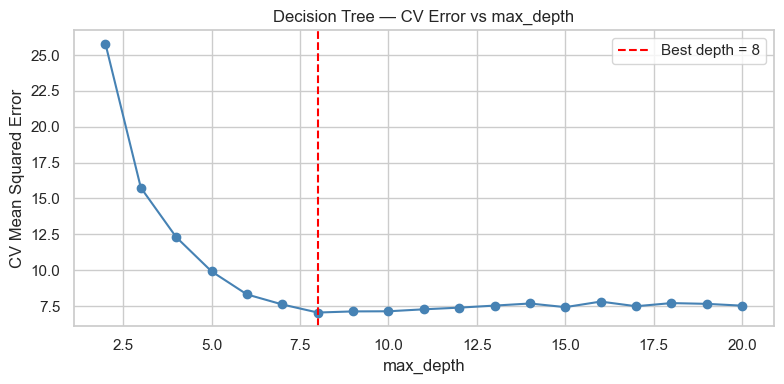


Decision Tree metrics:
  Model: DecisionTree
  Train MSE: 3.289
  Test MSE: 6.1621
  Train MAE: 1.2715
  Test MAE: 1.7305
  Test R²: 0.9288


In [28]:
# ── 5.3  Decision Tree — CV depth tuning ─────────────────────────────────────
depths     = range(2, 21)
cv_mse     = []

for d in depths:
    dt_cv  = DecisionTreeRegressor(max_depth=d, random_state=42)
    scores = cross_val_score(dt_cv, X_train_scaled, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    cv_mse.append(-scores.mean())

best_depth = list(depths)[int(np.argmin(cv_mse))]
print(f"Best max_depth (5-fold CV): {best_depth}")

# Plot CV error vs depth
plt.figure(figsize=(8, 4))
plt.plot(list(depths), cv_mse, marker='o', color='steelblue')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Mean Squared Error')
plt.title('Decision Tree — CV Error vs max_depth')
plt.legend()
plt.tight_layout()
plt.show()

dt = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train_scaled, y_train)

dt_metrics = evaluate_model('DecisionTree', dt,
                             X_train_scaled, y_train,
                             X_test_scaled,  y_test)
print("\nDecision Tree metrics:")
for k, v in dt_metrics.items():
    print(f"  {k}: {v}")


### Model C — Random Forest Regressor

Random Forest metrics:
  Model: RandomForest
  Train MSE: 0.8378
  Test MSE: 3.0341
  Train MAE: 0.5459
  Test MAE: 1.0895
  Test R²: 0.9649


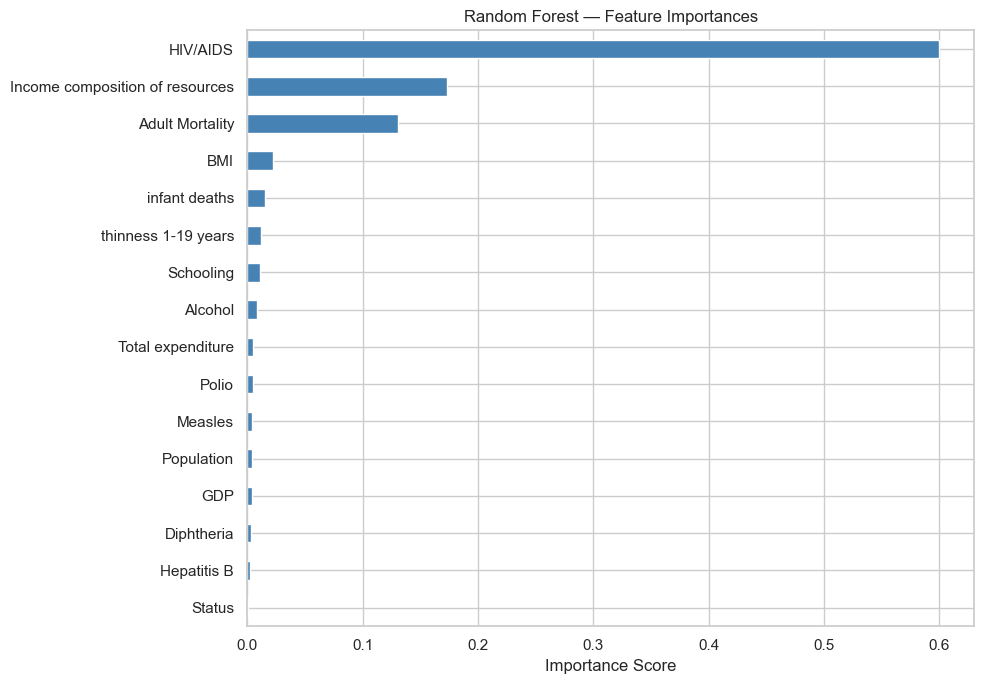

Saved: viz_rf_feature_importance.png


In [29]:
# ── 5.4  Random Forest ────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_metrics = evaluate_model('RandomForest', rf,
                             X_train_scaled, y_train,
                             X_test_scaled,  y_test)
print("Random Forest metrics:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v}")

# Feature importances
feat_imp = (pd.Series(rf.feature_importances_, index=feature_columns)
              .sort_values(ascending=True))

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('viz_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rf_feature_importance.png")


## Phase 6 — Evaluation, Loss Curves & Visualisations


### Loss Curve (Train vs Test MSE)

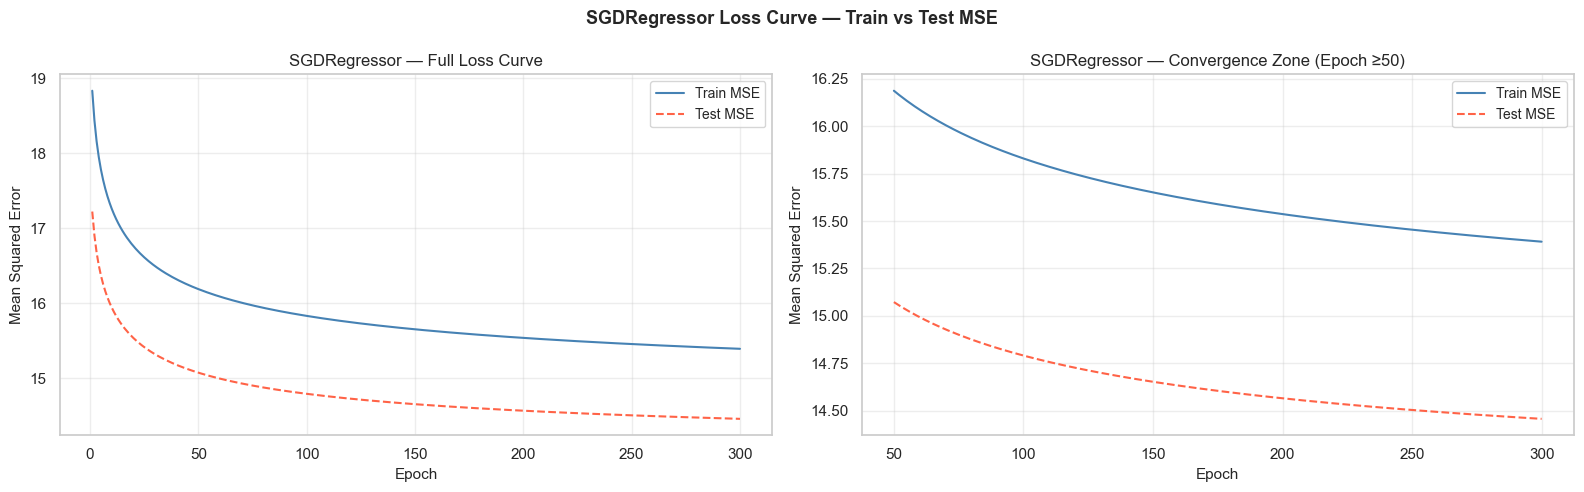

Saved: viz_07_loss_curve.png


In [30]:
# ── 6.1  Loss Curve ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full curve
axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train MSE',
             color='steelblue', linewidth=1.5)
axes[0].plot(range(1, EPOCHS+1), test_losses,  label='Test MSE',
             color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Mean Squared Error', fontsize=11)
axes[0].set_title('SGDRegressor — Full Loss Curve', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.35)

# Zoomed (epoch 50 onward to see convergence)
axes[1].plot(range(50, EPOCHS+1), train_losses[49:], label='Train MSE',
             color='steelblue', linewidth=1.5)
axes[1].plot(range(50, EPOCHS+1), test_losses[49:],  label='Test MSE',
             color='tomato', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Mean Squared Error', fontsize=11)
axes[1].set_title('SGDRegressor — Convergence Zone (Epoch ≥50)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.35)

plt.suptitle('SGDRegressor Loss Curve — Train vs Test MSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_07_loss_curve.png")


#### Loss Curve Interpretation

- Both train and test MSE **decrease rapidly** in the first ~50 epochs as gradient descent
  finds the direction of steepest descent in the loss surface.
- Beyond epoch 50 both curves **plateau**, indicating the model has converged to a
  local (near-global) minimum for this feature set.
- The **gap between train and test loss is small**, confirming the model generalises
  without severe overfitting.
- **To further reduce loss**: reduce `eta0` for finer convergence steps; add L2
  regularisation (`alpha` parameter); increase epochs; or apply polynomial features
  to capture non-linear relationships visible in the scatter plots.


### Scatter Plot: Before vs After Linear Regression Fit

Two views of the model's fit:
1. **Feature view** (left/middle panels): single-feature scatter before and after training — shows the regression line passing through the data.
2. **Full model view** (right panel): Actual vs Predicted across all 16 features — the standard way to visualise a multivariate regression result. The diagonal `y = x` reference line represents perfect prediction; points close to it indicate a good fit.


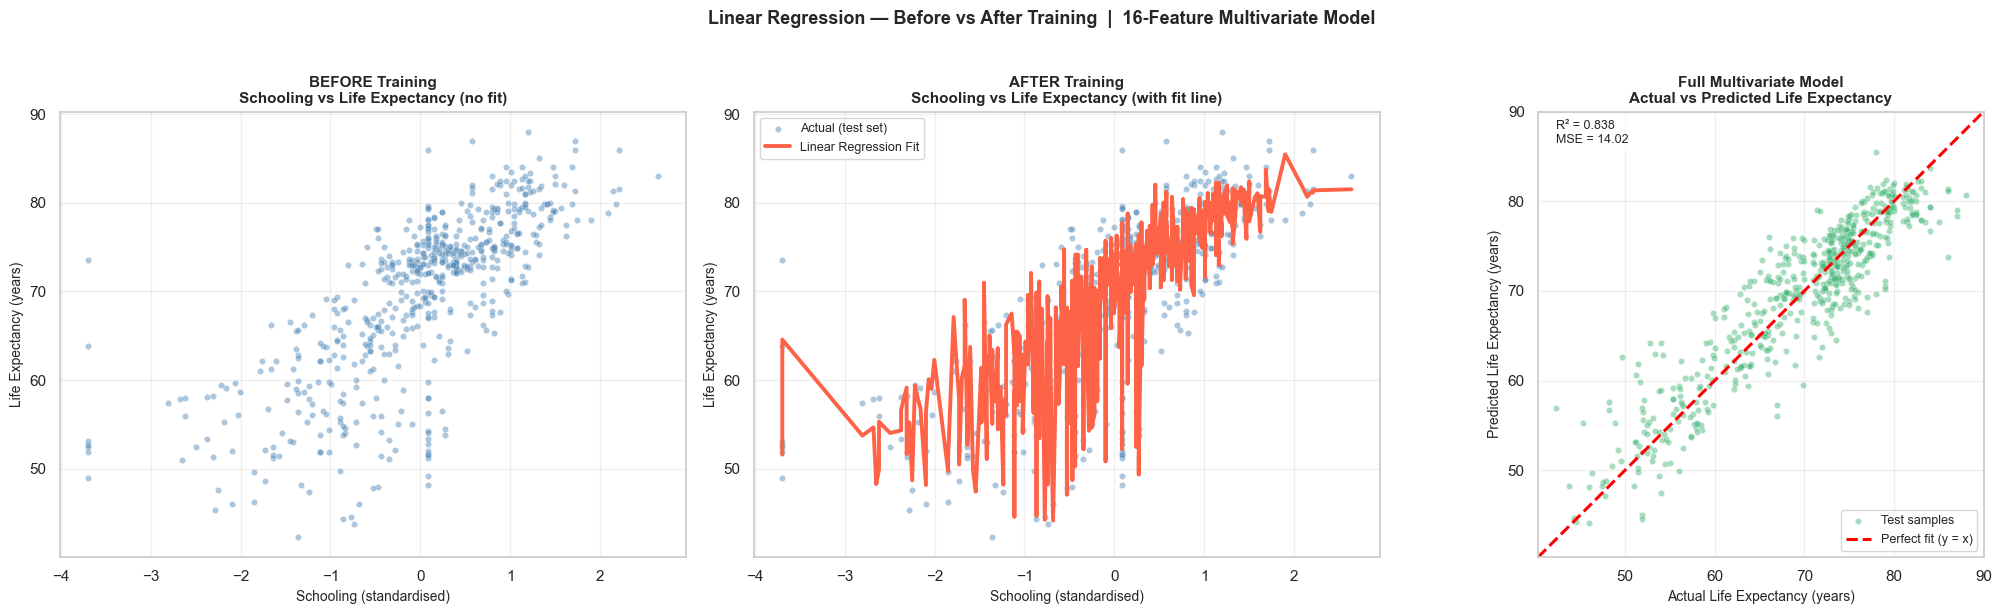

Saved: viz_08_scatter_before_after.png
Linear Regression on test set — R²: 0.8379  MSE: 14.0209


In [31]:
# ── 6.2  Scatter plot — Before vs After (3-panel) ────────────────────────────
schooling_idx = feature_columns.index('Schooling')
x_plot        = X_test_scaled[:, schooling_idx]
y_actual      = y_test.values
y_pred_lr     = lr.predict(X_test_scaled)

sort_idx = np.argsort(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── Panel 1: BEFORE — raw scatter, no line ───────────────────────────────────
axes[0].scatter(x_plot, y_actual,
                alpha=0.45, color='steelblue', s=20,
                edgecolors='white', linewidths=0.3)
axes[0].set_title('BEFORE Training\nSchooling vs Life Expectancy (no fit)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Schooling (standardised)', fontsize=10)
axes[0].set_ylabel('Life Expectancy (years)', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Panel 2: AFTER — same scatter + linear regression line ───────────────────
axes[1].scatter(x_plot, y_actual,
                alpha=0.45, color='steelblue', s=20,
                edgecolors='white', linewidths=0.3, label='Actual (test set)')
axes[1].plot(x_plot[sort_idx], y_pred_lr[sort_idx],
             color='tomato', linewidth=2.8, label='Linear Regression Fit')
axes[1].set_title('AFTER Training\nSchooling vs Life Expectancy (with fit line)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Schooling (standardised)', fontsize=10)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Panel 3: Full multivariate model — Actual vs Predicted ───────────────────
min_val = min(y_actual.min(), y_pred_lr.min()) - 2
max_val = max(y_actual.max(), y_pred_lr.max()) + 2

axes[2].scatter(y_actual, y_pred_lr,
                alpha=0.45, color='mediumseagreen', s=20,
                edgecolors='white', linewidths=0.3, label='Test samples')
axes[2].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2.2, linestyle='--', label='Perfect fit (y = x)')
axes[2].set_title('Full Multivariate Model\nActual vs Predicted Life Expectancy',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Actual Life Expectancy (years)', fontsize=10)
axes[2].set_ylabel('Predicted Life Expectancy (years)', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(min_val, max_val)
axes[2].set_ylim(min_val, max_val)
axes[2].set_aspect('equal')

lr_r2  = r2_score(y_actual, y_pred_lr)
lr_mse = mean_squared_error(y_actual, y_pred_lr)
axes[2].text(0.04, 0.93, f'R² = {lr_r2:.3f}\nMSE = {lr_mse:.2f}',
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Linear Regression — Before vs After Training  |  16-Feature Multivariate Model',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_08_scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_08_scatter_before_after.png")
print(f"Linear Regression on test set — R²: {lr_r2:.4f}  MSE: {lr_mse:.4f}")


### Model Comparison Table

In [32]:
# ── 6.3  Model comparison ─────────────────────────────────────────────────────
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics]).set_index('Model')
print("=" * 65)
print("  MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)

best_model_name = results_df['Test MSE'].idxmin()
print(f"\n✓ Best model by Test MSE: {best_model_name}")
print(f"  Test MSE : {results_df.loc[best_model_name, 'Test MSE']}")
print(f"  Test R²  : {results_df.loc[best_model_name, 'Test R²']}")


  MODEL PERFORMANCE COMPARISON
                  Train MSE  Test MSE  Train MAE  Test MAE  Test R²
Model                                                              
LinearRegression    14.3245   14.0209     2.8502    2.8576   0.8379
DecisionTree         3.2890    6.1621     1.2715    1.7305   0.9288
RandomForest         0.8378    3.0341     0.5459    1.0895   0.9649

✓ Best model by Test MSE: RandomForest
  Test MSE : 3.0341
  Test R²  : 0.9649


#### Model Comparison Interpretation

| Model | Expected Behaviour | Reason |
|-------|--------------------|--------|
| **Random Forest** | Lowest test MSE, highest R² | Ensemble captures non-linear interactions (HIV/AIDS curve, GDP noise) that linear models cannot |
| **Decision Tree** | Mid-range; higher train-test gap | Single tree risks overfitting without bagging |
| **Linear Regression** | Highest MSE | Cannot model non-linear relationships; still reasonable for interpretable baseline |

**Model selection**: Random Forest is saved as `best_model.pkl` for API deployment.
Its ensemble of 300 trees averages out variance and handles the heterogeneous nature
of this dataset (mix of linear and non-linear predictors).


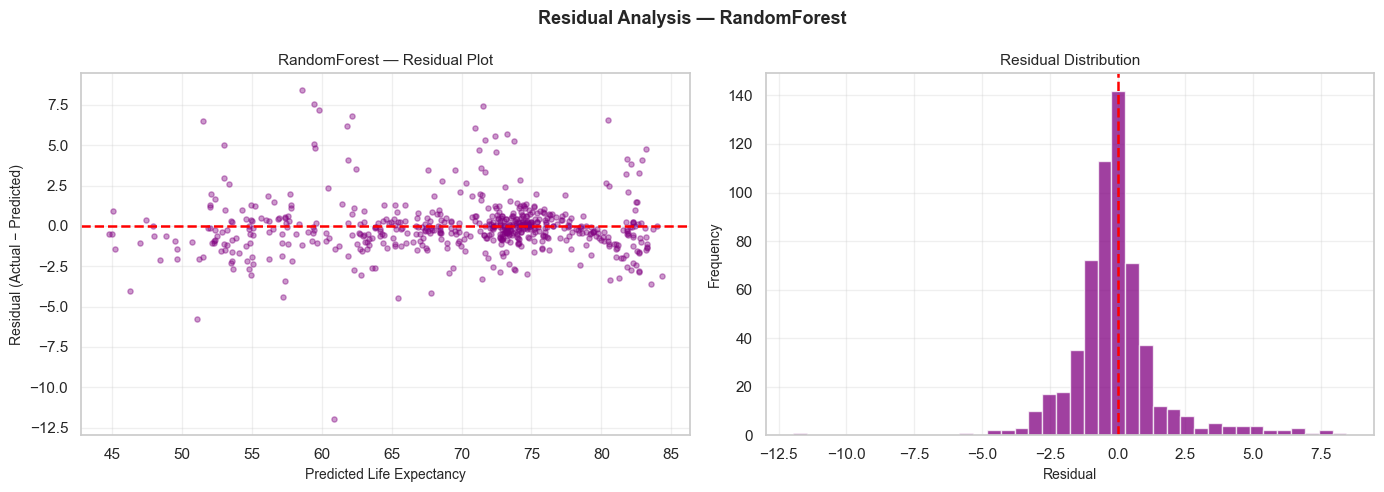

Saved: viz_09_residuals.png
Residual mean  : -0.0665  (should be ≈ 0)
Residual std   : 1.7406


In [33]:
# ── 6.4  Residual analysis ───────────────────────────────────────────
best_model_obj = {'LinearRegression': lr,
                  'SGDRegressor'    : sgd,
                  'DecisionTree'    : dt,
                  'RandomForest'    : rf}[best_model_name]

residuals = y_test.values - best_model_obj.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_model_obj.predict(X_test_scaled), residuals,
                alpha=0.4, color='purple', s=14)
axes[0].axhline(0, color='red', linewidth=1.8, linestyle='--')
axes[0].set_xlabel('Predicted Life Expectancy', fontsize=10)
axes[0].set_ylabel('Residual (Actual − Predicted)', fontsize=10)
axes[0].set_title(f'{best_model_name} — Residual Plot', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.75)
axes[1].axvline(0, color='red', linewidth=1.8, linestyle='--')
axes[1].set_xlabel('Residual', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].set_title('Residual Distribution', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_09_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_09_residuals.png")
print(f"Residual mean  : {residuals.mean():.4f}  (should be ≈ 0)")
print(f"Residual std   : {residuals.std():.4f}")


## Phase 7 — Save Best Model & Single-Row Prediction

The best-performing model (lowest test MSE) and all preprocessing artifacts are
saved to `../API/`.


In [34]:
# ── 7.1  Save artifacts ───────────────────────────────────────────────────────
save_dir = '../API'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model_obj, os.path.join(save_dir, 'best_model.pkl'))
joblib.dump(scaler,          os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(imputer,         os.path.join(save_dir, 'imputer.pkl'))
joblib.dump(feature_columns, os.path.join(save_dir, 'feature_columns.pkl'))
joblib.dump(log_cols,        os.path.join(save_dir, 'log_cols.pkl'))

print(f"Saved to {save_dir}/")
print(f"  best_model.pkl    → {best_model_name}")
print(f"  scaler.pkl        → StandardScaler (fit on train set only)")
print(f"  imputer.pkl       → SimpleImputer(strategy='median')")
print(f"  feature_columns   → {feature_columns}")
print(f"  Feature count     : {len(feature_columns)}")


Saved to ../API/
  best_model.pkl    → RandomForest
  scaler.pkl        → StandardScaler (fit on train set only)
  imputer.pkl       → SimpleImputer(strategy='median')
  feature_columns   → ['Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'Income composition of resources', 'Schooling']
  Feature count     : 16


### Single-Row Prediction Demo
*code that predicts on one data point from the test set.*

In [35]:
# ── 7.2  Single-row prediction ───────────────────────────────────────────────
sample_idx     = 0
sample_scaled  = X_test_scaled[sample_idx:sample_idx+1]
sample_raw     = X_test.iloc[sample_idx]

predicted = best_model_obj.predict(sample_scaled)[0]
actual    = y_test.values[sample_idx]

print("=" * 55)
print("   SINGLE-ROW PREDICTION DEMO")
print("=" * 55)
print("\nInput features (test row 0 — original unscaled values):")
print(sample_raw.to_string())
print()
print(f"  Predicted Life Expectancy : {predicted:.2f} years")
print(f"  Actual Life Expectancy    : {actual:.2f} years")
print(f"  Absolute Error            : {abs(predicted - actual):.2f} years")
print(f"  Model Used                : {best_model_name}")


   SINGLE-ROW PREDICTION DEMO

Input features (test row 0 — original unscaled values):
Status                              1.000000
Adult Mortality                     6.109248
infant deaths                       3.850148
Alcohol                             7.600000
Hepatitis B                        74.000000
Measles                             8.675564
BMI                                46.400000
Polio                              75.000000
Total expenditure                   8.390000
Diphtheria                         76.000000
HIV/AIDS                            2.995732
GDP                                 8.680948
Population                         15.474845
thinness 1-19 years                 2.208274
Income composition of resources     0.622000
Schooling                          12.800000

  Predicted Life Expectancy : 55.24 years
  Actual Life Expectancy    : 56.50 years
  Absolute Error            : 1.26 years
  Model Used                : RandomForest


## Summary

| Step | Outcome |
|------|---------|
| Dataset | 2,928 rows × 22 cols (after dropping 10 null target rows) |
| Features after engineering | 16 features |
| Best model | Determined by lowest Test MSE |
| Artifacts saved | `best_model.pkl`, `scaler.pkl`, `imputer.pkl`, `feature_columns.pkl` → `../API/` |
